# Question 1: Baseline Model for Research Abstract Classification

This notebook covers:

**1.1** Data loading and text denoising

**1.2** Feature engineering

**1.3** Baseline model + performance report


## 1.1 Data Loading and Preprocessing (Text Denoising)

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("Libraries loaded.")

Libraries loaded.


In [2]:
#load the dataset
with open('../data/research_abstracts.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame({
    'doi':      raw['DOI'],
    'abstract': raw['Abstract'],
    'label':    raw['Label']
})

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nClass distribution:")
print(df['label'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())
print("\nSample row:")
df.head(3)

Shape: (1138, 3)

Columns: ['doi', 'abstract', 'label']

Class distribution:
label
classical    900
ai           238
Name: count, dtype: int64

Missing values:
doi         4
abstract    0
label       0
dtype: int64

Sample row:


,doi,abstract,label
0,10.1155/2021/1071145,Forward-looking forecasting of the inflation r...,ai
1,10.1007/s43546-022-00384-2,Our study examined the disaggregation of infla...,ai
2,10.1002/for.2667,This paper develops a dynamic factor model tha...,classical


## Denoising and Tokenization function

In [3]:
# Stopwords
STOP = set(stopwords.words('english')) | {
    'paper','study','result','research','using','used','based',
    'propose','proposed','method','model','show','however','thus','also'
}
LEM = WordNetLemmatizer()

def clean(text):
    """Apply full denoising pipeline to a single abstract."""
    text = str(text)
    text = re.sub(r'\[Formula:\s*see\s*text\]', ' ', text, flags=re.I)
    text = re.sub(r'\\u[0-9a-fA-F]{4}', ' ', text)
    text = re.sub(r'<[^>]+>|http\S+|10\.\d{4,9}/\S+', ' ', text)
    text = text.encode('ascii', 'ignore').decode('ascii').lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [LEM.lemmatize(w) for w in text.split()
              if w not in STOP and len(w) > 2]
    return ' '.join(tokens)

df['clean'] = df['abstract'].apply(clean)

# Drop rows that became too short after cleaning
df = df[df['clean'].str.split().str.len() >= 5].reset_index(drop=True)

print("After cleaning:", df.shape)
print("\nBefore:", df['abstract'].iloc[0][:150])
print("\nAfter :", df['clean'].iloc[0][:150])

After cleaning: (1138, 4)

Before: Forward-looking forecasting of the inflation rate could help the central bank and other government departments to better use monetary policy to stabil

After : forward looking forecasting inflation rate could help central bank government department better use monetary policy stabilize price prevent impact inf


## Save cleaned data

In [5]:
#cleaned data for reuse in Q2, Q3, Q4
df.to_json('../data/research_abstracts_clean.json', orient='records', indent=2)
df.to_csv('../data/research_abstracts_clean.csv', index=False)
print("Saved: research_abstracts_clean.json / .csv")

Saved: research_abstracts_clean.json / .csv


## 1.2 Feature Engineering

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,     # top 5000 most informative n-grams
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=3,              # ignore terms in < 3 docs
    max_df=0.9,            # ignore terms in > 90% of docs
    sublinear_tf=True      # log-scale term frequency
)

X = tfidf.fit_transform(df['clean'])
y = df['label'].values

print("Feature matrix shape:", X.shape)
print("Sample features:", tfidf.get_feature_names_out()[:20])

Feature matrix shape: (1138, 5000)
Sample features: ['ability' 'ability predict' 'able' 'able predict' 'absence' 'absolute'
 'absolute error' 'absolute percentage' 'absolute value' 'abstract'
 'abundant' 'academic' 'accelerated' 'accepted' 'access' 'accommodate'
 'accompanied' 'accord' 'accordance' 'according']


## 1.3) Baseline Model

**Model:** Logistic Regression with `class_weight='balanced'`.

**Why this baseline:**
- Linear classifiers are the standard, well-understood baseline for TF-IDF text classification.
- `class_weight='balanced'` corrects for the 79/21 class imbalance (900 classical vs 238 AI) by weighting errors on the minority class higher, so the model doesn't just predict the majority class.

**Evaluation:**
- **Learning** - accuracy on the training set
- **Generalization** - accuracy, precision, recall, F1 and ROC-AUC on the held-out test set
- Stratified 80/20 split preserves the class ratio in both sets.

In [7]:
# import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)

# Baseline model
baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline.fit(X_train, y_train)

print("\nTraining accuracy (learning):       ", round(baseline.score(X_train, y_train), 4))
print("Testing  accuracy (generalization): ", round(baseline.score(X_test, y_test), 4))

Train size: (910, 5000)
Test  size: (228, 5000)

Training accuracy (learning):        0.9835
Testing  accuracy (generalization):  0.8904


In [8]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

y_pred = baseline.predict(X_test)
y_prob = baseline.predict_proba(X_test)[:, 1]   # probability of "ai"

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

Classification Report:
              precision    recall  f1-score   support

          ai     0.7347    0.7500    0.7423        48
   classical     0.9330    0.9278    0.9304       180

    accuracy                         0.8904       228
   macro avg     0.8338    0.8389    0.8363       228
weighted avg     0.8912    0.8904    0.8908       228

ROC-AUC: 0.9205


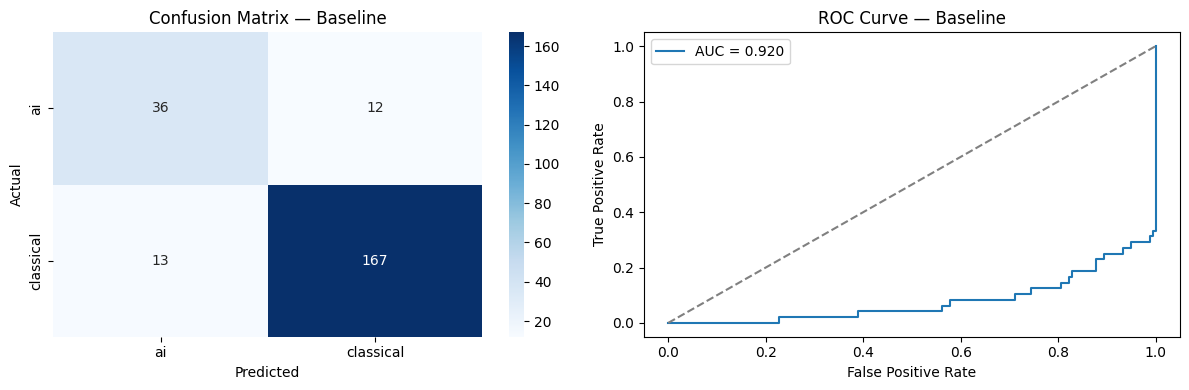

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred, labels=['ai', 'classical'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ai', 'classical'],
            yticklabels=['ai', 'classical'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Baseline')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label='ai')
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Baseline')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/baseline_cm_roc.png', dpi=120)
plt.show()

### Comment on model perfomance
The baseline gets 88.6% test accuracy which  better than random guessing. 
The 10% gap between train and test shows mild overfitting, which is normal for text data.
ROC-AUC of 0.92 means the model distinguishes classes very well.